In [17]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.2 MB ? eta -:--:--Downloading matplotlib-3.10.9-cp311-cp311-macosx_11_0_arm64.whl (8.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 6.0 MB/s  0:00:01 eta 0:00:01m
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 6.0 MB/s  0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/2.9 MB ? eta -:--:--Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv('train.csv')

df.shape        # how many rows/cols?
df.head(10)     # what does the data look like?
df.dtypes       # what types are the columns?
df.describe()   # stats: mean, std, min, max
df.isnull().sum()  # CRITICAL: where is data missing?

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

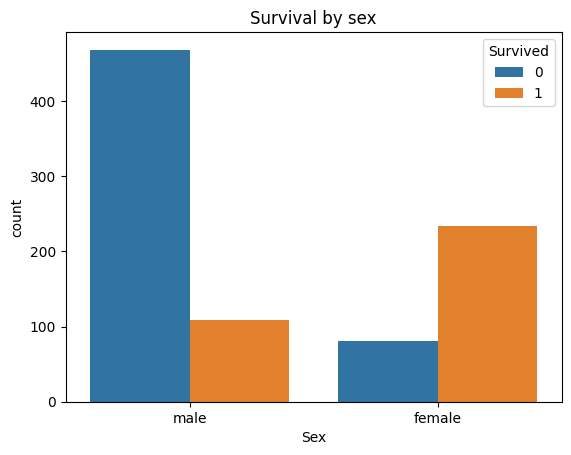

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival by sex')
plt.show()

# What % of women survived vs men?
df.groupby('Sex')['Survived'].mean()

this tells us that felmale has survived more than man

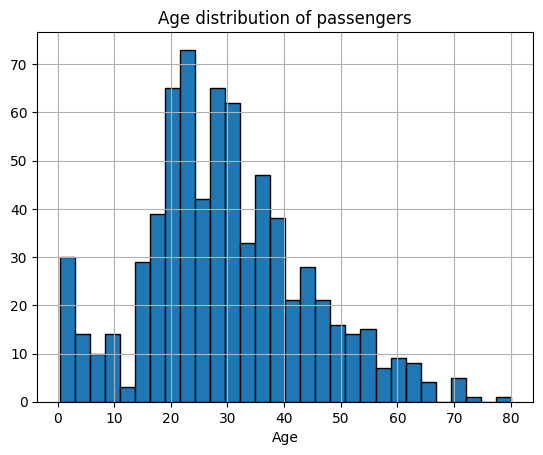

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,30.626179,14.172110,1.00,21.0,28.0,39.0,74.0
1,290.0,28.343690,14.950952,0.42,19.0,28.0,36.0,80.0


In [20]:
df['Age'].hist(bins=30, edgecolor='black')
plt.xlabel('Age')
plt.title('Age distribution of passengers')
plt.show()

# Age by survival
df.groupby('Survived')['Age'].describe()

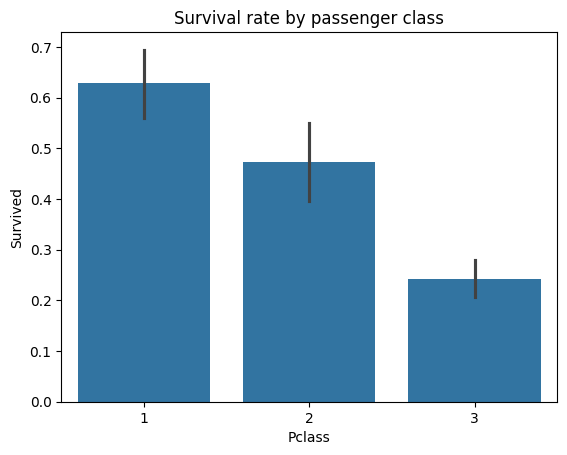

In [21]:
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival rate by passenger class')
plt.show()

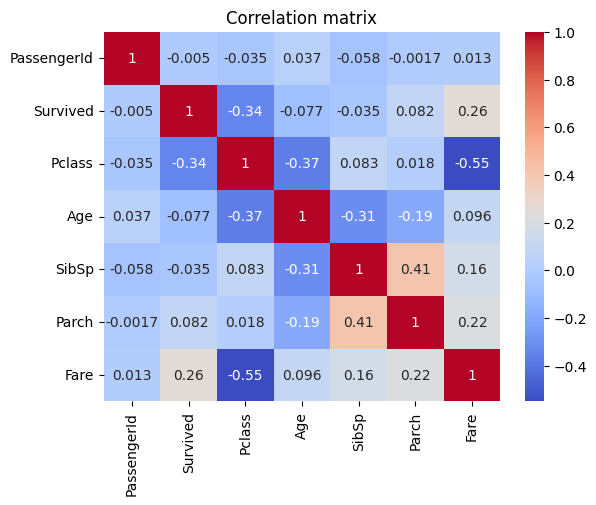

In [22]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation matrix')
plt.show()

In [23]:
df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack()

df.groupby('Embarked')['Survived'].mean()

df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.groupby('FamilySize')['Survived'].mean()

FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64